In [1]:
import os
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "tensorflow"
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import random
RNG = np.random.default_rng(2023)
from scipy.stats import beta
from scipy.spatial.distance import cdist

import keras
import bayesflow as bf
from functools import partial

import numba as nb
from numba import float32, int32
import logging
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)

import pandas as pd

2026-05-07 09:53:27.008357: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 09:53:33.284464: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-07 09:53:52.580929: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
INFO:bayesflow:Using backend 'tensorflow'


In [2]:
import importlib, sys, subprocess

print("=== Python ===")
print(sys.version)

print("\n=== Package Versions ===")
for pkg_name in ["keras", "bayesflow", "numpy", "pandas", "matplotlib", "seaborn", "numba", "tensorflow"]:
    try:
        mod = importlib.import_module(pkg_name)
        print(f"{pkg_name}: {getattr(mod, '__version__', 'unknown')}")
    except ImportError:
        print(f"{pkg_name}: NOT INSTALLED")

import shutil, pathlib

# Find and delete numba cache
for p in pathlib.Path('.').rglob('__pycache__'):
    shutil.rmtree(p)
print("Cache cleared")

=== Python ===
3.11.3 (main, Jun 12 2025, 13:20:10) [GCC 12.3.0]

=== Package Versions ===
keras: 3.11.3
bayesflow: 2.0.6
numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.10.6
seaborn: 0.13.2
numba: 0.62.1
tensorflow: 2.20.0
Cache cleared


## Single trial simulation
The following cells implement the core simulation.
**You do not need to modify this code** to customize the model.

In [3]:
@nb.jit(nopython=True)
def rbf_kernel(x1, x2, rho):
    diff = x1 - x2
    return math.exp(-0.5 * diff * diff / (rho * rho))

@nb.jit(nopython=True)
def beta_pdf(x, alpha, beta):
    if x <= 0.0 or x >= 1.0 or alpha <= 0.0 or beta <= 0.0:
        return 0.0
    log_pdf = ((alpha - 1.0) * math.log(x)
             + (beta  - 1.0) * math.log(1.0 - x)
             - (math.lgamma(alpha) + math.lgamma(beta) - math.lgamma(alpha + beta)))
    return math.exp(log_pdf)

@nb.jit(nopython=True)
def cholesky_inplace(A, n):
    for i in range(n):
        for j in range(i + 1):
            s = 0.0
            for k in range(j):
                s += A[i, k] * A[j, k]
            if i == j:
                val = A[i, i] - s
                A[i, j] = math.sqrt(val if val > 0.0 else 1e-8)
            else:
                A[i, j] = (A[i, j] - s) / A[j, j] if A[j, j] != 0.0 else 0.0

@nb.jit(nopython=True, cache = True, fastmath=True)
def bddm_trial(mu, kappa, h, a, ndt, rho, x, dt, max_steps):
    """Single trial simulation of the BDDM on CPU."""
    n = x.shape[0]

    # --- Drift profile ---
    drift_profile = np.zeros(n)
    for i in range(n):
        drift_profile[i] = h * beta_pdf(x[i], mu * kappa, kappa - mu * kappa)

    # --- RBF kernel + Cholesky ---
    K = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            K[i, j] = rbf_kernel(x[i], x[j], rho)
    for i in range(n):
        K[i, i] += 1e-6  # jitter for numerical stability
    cholesky_inplace(K, n)  # K now holds L (lower triangular)

    # --- Initialize ---
    f     = np.zeros(n)
    f_new = np.zeros(n)
    z     = np.zeros(n)

    stop_time = float(max_steps) * dt  # fallback
    sqrt_dt = math.sqrt(dt)
    # --- Time integration ---
    for t in range(max_steps):

        # Sample noise
        z = np.random.randn(n)
        Lz = np.dot(K, z)
        f_new = f + drift_profile * dt + Lz * sqrt_dt
        f = f_new - f_new.mean()
        if np.any(f >= a):
            stop_time = (t + 1) * dt
            break
 
    # --- Response = argmax of f ---
    max_idx = np.argmax(f)

    rt   = stop_time + ndt
    resp = x[max_idx]
    return rt, resp

## ⚙️ Prior (customizable)

This function defines the prior distributions over all model parameters.
Modify the ranges below to match your experimental design.

### Parameter guide

| Parameter | Shape | Description | Default range |
|-----------|-------|-------------|---------------|
| `mu` | `(n_conditions,)` | Location of drift rate function | [0.15, 0.85] |
| `kappa` | `(n_conditions,)` | Concentration of drift rate function | [1/mu, 20] |
| `h` | `(n_conditions,)` | Scale parameter of the drift rate function | [0.2, 3] |
| `a` | scalar | Decision threshold | [0.5, 7] |
| `ndt` | scalar | Non-decision time (seconds) | [0.1, 2.5] |
| `rho` | scalar | RBF kernel lengthscale | [0.01, 0.5] |

### Common modifications

**Change parameter ranges** (modify the numbers to match your experiment):

```python
mu  = rng.uniform(0.15, 0.85, size=(4,))
h   = rng.uniform(0.2, 3, size=(4,))
a   = rng.uniform(0.5, 7)
ndt = rng.uniform(0.1, 2.5)
rho = rng.uniform(0.01, 0.5)
```

**Change number of conditions** (replace 4 with your n_conditions):

```python
mu  = rng.uniform(0.15, 0.85, size=(4,))
h   = rng.uniform(0.2, 3, size=(4,))
```

**Make a shared parameter condition-specific** (example for `a`):

```python
a = rng.uniform(0.5, 7)
a = rng.uniform(0.5, 7, size=(4,))
```

**Note on `kappa`:** the lower bound depends on `mu` and cannot be changed independently.
To modify the upper bound:

```python
kappa = rng.uniform(minimum_kappa, np.full_like(minimum_kappa, 20))
```

Replace 20 with your desired upper bound.


In [4]:
def bddm_prior(batch_size, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    mu  = rng.uniform(0.15, 0.85, size=(batch_size, 4))
    minimum_kappa = np.maximum(1/mu, 1/(1-mu))
    kappa = rng.uniform(minimum_kappa, np.full_like(minimum_kappa, 20))
    h   = rng.uniform(0.2, 3, size=(batch_size, 4))
    a   = rng.uniform(0.5, 7, size=batch_size)
    ndt = rng.uniform(0.1, 2.5, size=batch_size)
    rho = rng.uniform(0.01, 0.5, size=batch_size)
    return dict(mu=mu, kappa=kappa, h=h, a=a, ndt=ndt, rho=rho)

## ⚙️ Experiment Setup (customizable)

### Parameters you may need to modify

**Number of observations per condition** (default: 39-50):

```python
min_obs = 39
max_obs = 50
```

**Number of accumulators** (default: 101, higher = more precise but slower):

```python
X_FIXED = np.linspace(0, 1, 101)
```

**Number of conditions** (default: 4, replace 4 with your n_conditions):

```python
labels = np.repeat(np.arange(4), num_obs_per_condition)
con = np.eye(4)[labels]
```

**Simulation precision:**

```python
rt, resp = bddm_trial(..., dt=1e-3, max_steps=15000)
```

Replace dt with a smaller value for more precision, or reduce max_steps for faster simulation.

**If you made `a`, `ndt`, or `rho` condition-specific in the prior:**

```python
rt_out[b, :n] = rt
```

Update the indexing in bddm_experiment_nb accordingly:

```python
rt, resp = bddm_trial(mu[idx], kappa[idx], h[idx], a[idx], ndt[idx], rho[idx], X_FIXED, dt=1e-3, max_steps=15000)
```

### Do not modify

- bddm_batch_nb — Numba parallel kernel, changing parallel structure may cause errors
- The labels indexing logic — handles condition assignment correctly
- full_batched_simulator — handles batching and padding, only modify if you changed n_conditions or added parameters

In [5]:
#design matrix
min_obs = 39
max_obs = 50
def meta(num_obs_per_condition=None):
    num_obs_per_condition = np.random.randint(min_obs, max_obs, size=(4,))
    return dict(num_obs_per_condition=num_obs_per_condition)

In [6]:
X_FIXED = np.linspace(0,1,101)

@nb.jit(nopython=True, parallel=False, cache=True)
def bddm_experiment_nb(mu, kappa, h, a, ndt, rho, num_obs_per_condition):
    labels = np.repeat(np.arange(4), num_obs_per_condition)
    num_obs = len(labels)
    rt_out   = np.zeros(num_obs)
    resp_out = np.zeros(num_obs)
    for n in range(num_obs): 
        idx = labels[n]
        rt, resp = bddm_trial(mu[idx], kappa[idx], h[idx], a, ndt, rho,
                              X_FIXED, dt=1e-3, max_steps=15000)
        rt_out[n] = rt
        resp_out[n] = resp
    return rt_out, resp_out, labels


def bddm_experiment(mu, kappa, h, a, ndt, rho, num_obs_per_condition, rng=None):
    batch_size = mu.shape[0]
    max_len = max_obs * 4
    rt_out, resp_out = bddm_batch_nb(
        mu, kappa, h, a, ndt, rho,
        num_obs_per_condition.astype(np.int64)
    )
    labels = np.repeat(np.arange(4), num_obs_per_condition[0])
    con = np.eye(4)[labels]
    con_padded = np.zeros((batch_size, max_len, 4))
    con_padded[:, :len(labels), :] = con
    return dict(rt=rt_out, resp=resp_out, con=con_padded)

@nb.jit(nopython=True, parallel=True, cache=True)
def bddm_batch_nb(all_mu, all_kappa, all_h, all_a, all_ndt, all_rho, all_num_obs):
    B = all_mu.shape[0]
    max_len = max_obs * 4  # 200
    
    rt_out   = np.zeros((B, max_len))
    resp_out = np.zeros((B, max_len))
    
    for b in nb.prange(B):
        rt, resp, _ = bddm_experiment_nb(
            all_mu[b], all_kappa[b], all_h[b],
            all_a[b], all_ndt[b], all_rho[b],
            all_num_obs[b]
        )
        n = len(rt)
        rt_out[b, :n]   = rt
        resp_out[b, :n] = resp
    
    return rt_out, resp_out

def full_batched_simulator(batch_info):
    batch_size = batch_info[0] if isinstance(batch_info, tuple) else batch_info
    
    # prior
    params = bddm_prior(batch_size)
    num_obs_per_condition = np.random.randint(min_obs, max_obs, size=(4,)).astype(np.int64)
    
    # simulate
    rt_out, resp_out = bddm_batch_nb(
        params['mu'], params['kappa'], params['h'],
        params['a'], params['ndt'], params['rho'],
        np.tile(num_obs_per_condition, (batch_size, 1))
    )
    
    # con
    labels = np.repeat(np.arange(4), num_obs_per_condition)
    con = np.eye(4)[labels]
    con_padded = np.zeros((batch_size, max_obs * 4, 4))
    con_padded[:, :len(labels), :] = con
    
    return {
        "num_obs_per_condition": np.tile(num_obs_per_condition, (batch_size, 1)),
        **params,
        "a":   params['a'][:, np.newaxis],
        "ndt": params['ndt'][:, np.newaxis],
        "rho": params['rho'][:, np.newaxis],
        "rt":   rt_out[..., np.newaxis],
        "resp": resp_out[..., np.newaxis],
        "con":  con_padded
    }

bddm_simulator = bf.simulators.make_simulator(full_batched_simulator, is_batched=True)

In [7]:
%time sim_data = bddm_simulator.sample(batch_size = 200)

CPU times: user 1min 16s, sys: 48.2 ms, total: 1min 16s
Wall time: 6.93 s


## Simulate and Save Training Data

This section generates the training data for offline training.
Simulation is done in chunks to avoid memory overflow.

### Parameters you may need to modify

**Total number of datasets** (default: 20,000 for CPU tutorial):

```python
total = 20_000
```

**Chunk size** (default: 200, reduce if you run out of memory):

```python
chunk_size = 200
```

**Save path** (change to your own scratch directory):

```python
np.savez("../training_data/bddm_training_data_cpu.npz", **training_data)
```

### Note

If you already have a saved file, skip the simulation and load directly:

```python
training_data_saved = {k: v[:] for k, v in np.load("path/to/file.npz").items()}
```

Always load with v[:] to force data into RAM, otherwise training will be slow.

In [8]:
chunk_size = 200
total = 100_000
chunks = []

In [ ]:
for i in range(total // chunk_size):
    chunk = bddm_simulator.sample(chunk_size)
    chunks.append(chunk)
    if i % 50 == 0:
        print(f"{i * chunk_size}/{total}")
        
training_data = {key: np.concatenate([c[key] for c in chunks], axis=0) 
            for key in chunks[0].keys()}

#np.savez("/scratch/leuven/361/vsc36114/bddm_training_data_cpu.npz", **training_data)
np.savez("../training_data/bddm_training_data_cpu.npz", **training_data)

0/100000


In [7]:
training_data = {k: v[:] for k, v in np.load("../training_data/bddm_training_data_cpu.npz").items()}

## Adapter, Network, and Training Setup (customizable)

### Adapter

**If you added or removed parameters in the prior**, update these lines:

```python
.constrain("mu", lower=0, upper=1)
.constrain("kappa", lower=0)
...
.concatenate(["mu", "kappa", "h", "a", "ndt", "rho"], into="inference_variables")
```

**If you made `a`, `ndt`, or `rho` condition-specific**, no changes needed here.

### Network architecture

```python
summary_network = bf.networks.SetTransformer(summary_dim=40)
inference_network = bf.networks.FlowMatching(
    subnet="mlp",
    subnet_kwargs={"widths": (128,)*5}
)
```

Reduce widths for faster training, e.g. (64,)*3 for a lightweight version.

### Training

```python
epochs = 30
num_batches = 512
batch_size = 256
```

**Change checkpoint name** to avoid overwriting previous runs:

```python
checkpoint_name = "bddm_cpu"
```

**To resume training from a saved checkpoint:**

```python
workflow.approximator = keras.saving.load_model("../networks/bddm_cpu.keras")
```

In [14]:
adapter = (
    bf.Adapter()
    .sqrt("num_obs_per_condition")
    .constrain("mu", lower=0, upper = 1)
    .constrain("kappa", lower=0)
    .constrain("h", lower=0)
    .constrain("a", lower=0)
    .constrain("ndt", lower=0)
    .constrain("rho", lower=0)
    .concatenate(["mu", "kappa", "h", "a", "ndt", "rho"], into = "inference_variables")
    .as_set(["rt", "resp", "con"])
    .concatenate(["rt", "resp", "con"], into = "summary_variables")
    .concatenate(["num_obs_per_condition"], into = "inference_conditions"))



In [32]:
summary_network = bf.networks.SetTransformer(summary_dim=40)     
inference_network = bf.networks.FlowMatching(
    subnet="mlp", 
    subnet_kwargs={"widths": (128,)*5})

In [33]:
epochs = 100
num_batches = 512
batch_size = 256
learning_rate = keras.optimizers.schedules.CosineDecay(5e-4, decay_steps=epochs*num_batches, alpha=1e-6)
optimizer = keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)

workflow = bf.BasicWorkflow(
    simulator=bddm_simulator,
    adapter=adapter,
    inference_network=inference_network,
    summary_network=summary_network,
    initial_learning_rate=5e-4,
    optimizer = optimizer,
    checkpoint_filepath =  "../networks",
    checkpoint_name = "bddm_cpu"
)

In [34]:
workflow.approximator = keras.saving.load_model("../networks/bddm_cpu.keras")

In [ ]:
history = workflow.fit_offline(
     epochs=epochs,
     data = training_data,
     batch_size=batch_size,
     num_batches_per_epoch=num_batches,
     validation_data = 100,
 )

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 249s 617ms/step - loss: 3.4028 - val_loss: 1.7786
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 240s 613ms/step - loss: 1.6407 - val_loss: 1.4542
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 239s 611ms/step - loss: 1.3855 - val_loss: 1.2547
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 235s 602ms/step - loss: 1.2330 - val_loss: 1.1735
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 237s 607ms/step - loss: 1.1528 - val_loss: 1.1158
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 238s 608ms/step - loss: 1.1165 - val_loss: 1.0270
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 237s 606ms/step - loss: 1.0824 - val_loss: 0.9846
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 237s 607ms/step - loss: 1.0624 - val_loss: 1.0027
Epoch 9/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 236s 604ms/step - loss: 1.0489 - val_loss: 1.0263
Epoch 10/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 237s 606ms/step - loss: 1.0331 - val_loss: 0.9942
Epoch 11/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 238s 608ms/step - loss: 1.0209 - val_loss: 0.96

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



391/391 ━━━━━━━━━━━━━━━━━━━━ 246s 630ms/step - loss: 0.9378 - val_loss: 0.8259
Epoch 26/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 247s 631ms/step - loss: 0.9306 - val_loss: 0.8343
Epoch 27/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 246s 630ms/step - loss: 0.9251 - val_loss: 0.8890
Epoch 28/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 247s 632ms/step - loss: 0.9230 - val_loss: 0.8529
Epoch 29/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 248s 633ms/step - loss: 0.9164 - val_loss: 0.8919
Epoch 30/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 249s 637ms/step - loss: 0.9158 - val_loss: 0.9393
Epoch 31/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 251s 642ms/step - loss: 0.9106 - val_loss: 0.8987
Epoch 32/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 251s 642ms/step - loss: 0.9089 - val_loss: 0.7918
Epoch 33/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 252s 644ms/step - loss: 0.9048 - val_loss: 0.8538
Epoch 34/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 252s 644ms/step - loss: 0.9030 - val_loss: 0.8146
Epoch 35/100
204/391 ━━━━━━━━━━━━━━━━━━━━ 2:00 644ms/step - loss: 0.9037

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



391/391 ━━━━━━━━━━━━━━━━━━━━ 252s 645ms/step - loss: 0.8934 - val_loss: 0.8312
Epoch 39/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 240s 614ms/step - loss: 0.8890 - val_loss: 0.8539
Epoch 41/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 237s 605ms/step - loss: 0.8875 - val_loss: 0.8602
Epoch 42/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 225s 574ms/step - loss: 0.8860 - val_loss: 0.8688
Epoch 43/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 222s 568ms/step - loss: 0.8862 - val_loss: 0.8435
Epoch 44/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 224s 572ms/step - loss: 0.8805 - val_loss: 0.8333
Epoch 45/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 224s 573ms/step - loss: 0.8817 - val_loss: 0.7607
Epoch 46/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 224s 573ms/step - loss: 0.8803 - val_loss: 0.8844
Epoch 47/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 224s 573ms/step - loss: 0.8772 - val_loss: 0.8529
Epoch 48/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 224s 573ms/step - loss: 0.8764 - val_loss: 0.8004
Epoch 49/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 224s 572ms/step - loss: 0.8768 - val_loss: 0.8643
E

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



238/391 ━━━━━━━━━━━━━━━━━━━━ 1:29 584ms/step - loss: 0.8691

In [68]:
# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = bddm_simulator.sample(200)

# Obtain num_samples samples of the parameter posterior for every validation dataset
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)

# post_draws is a dictionary of draws with one element per named parameters
post_draws.keys() 

dict_keys(['mu', 'kappa', 'h', 'a', 'ndt', 'rho'])

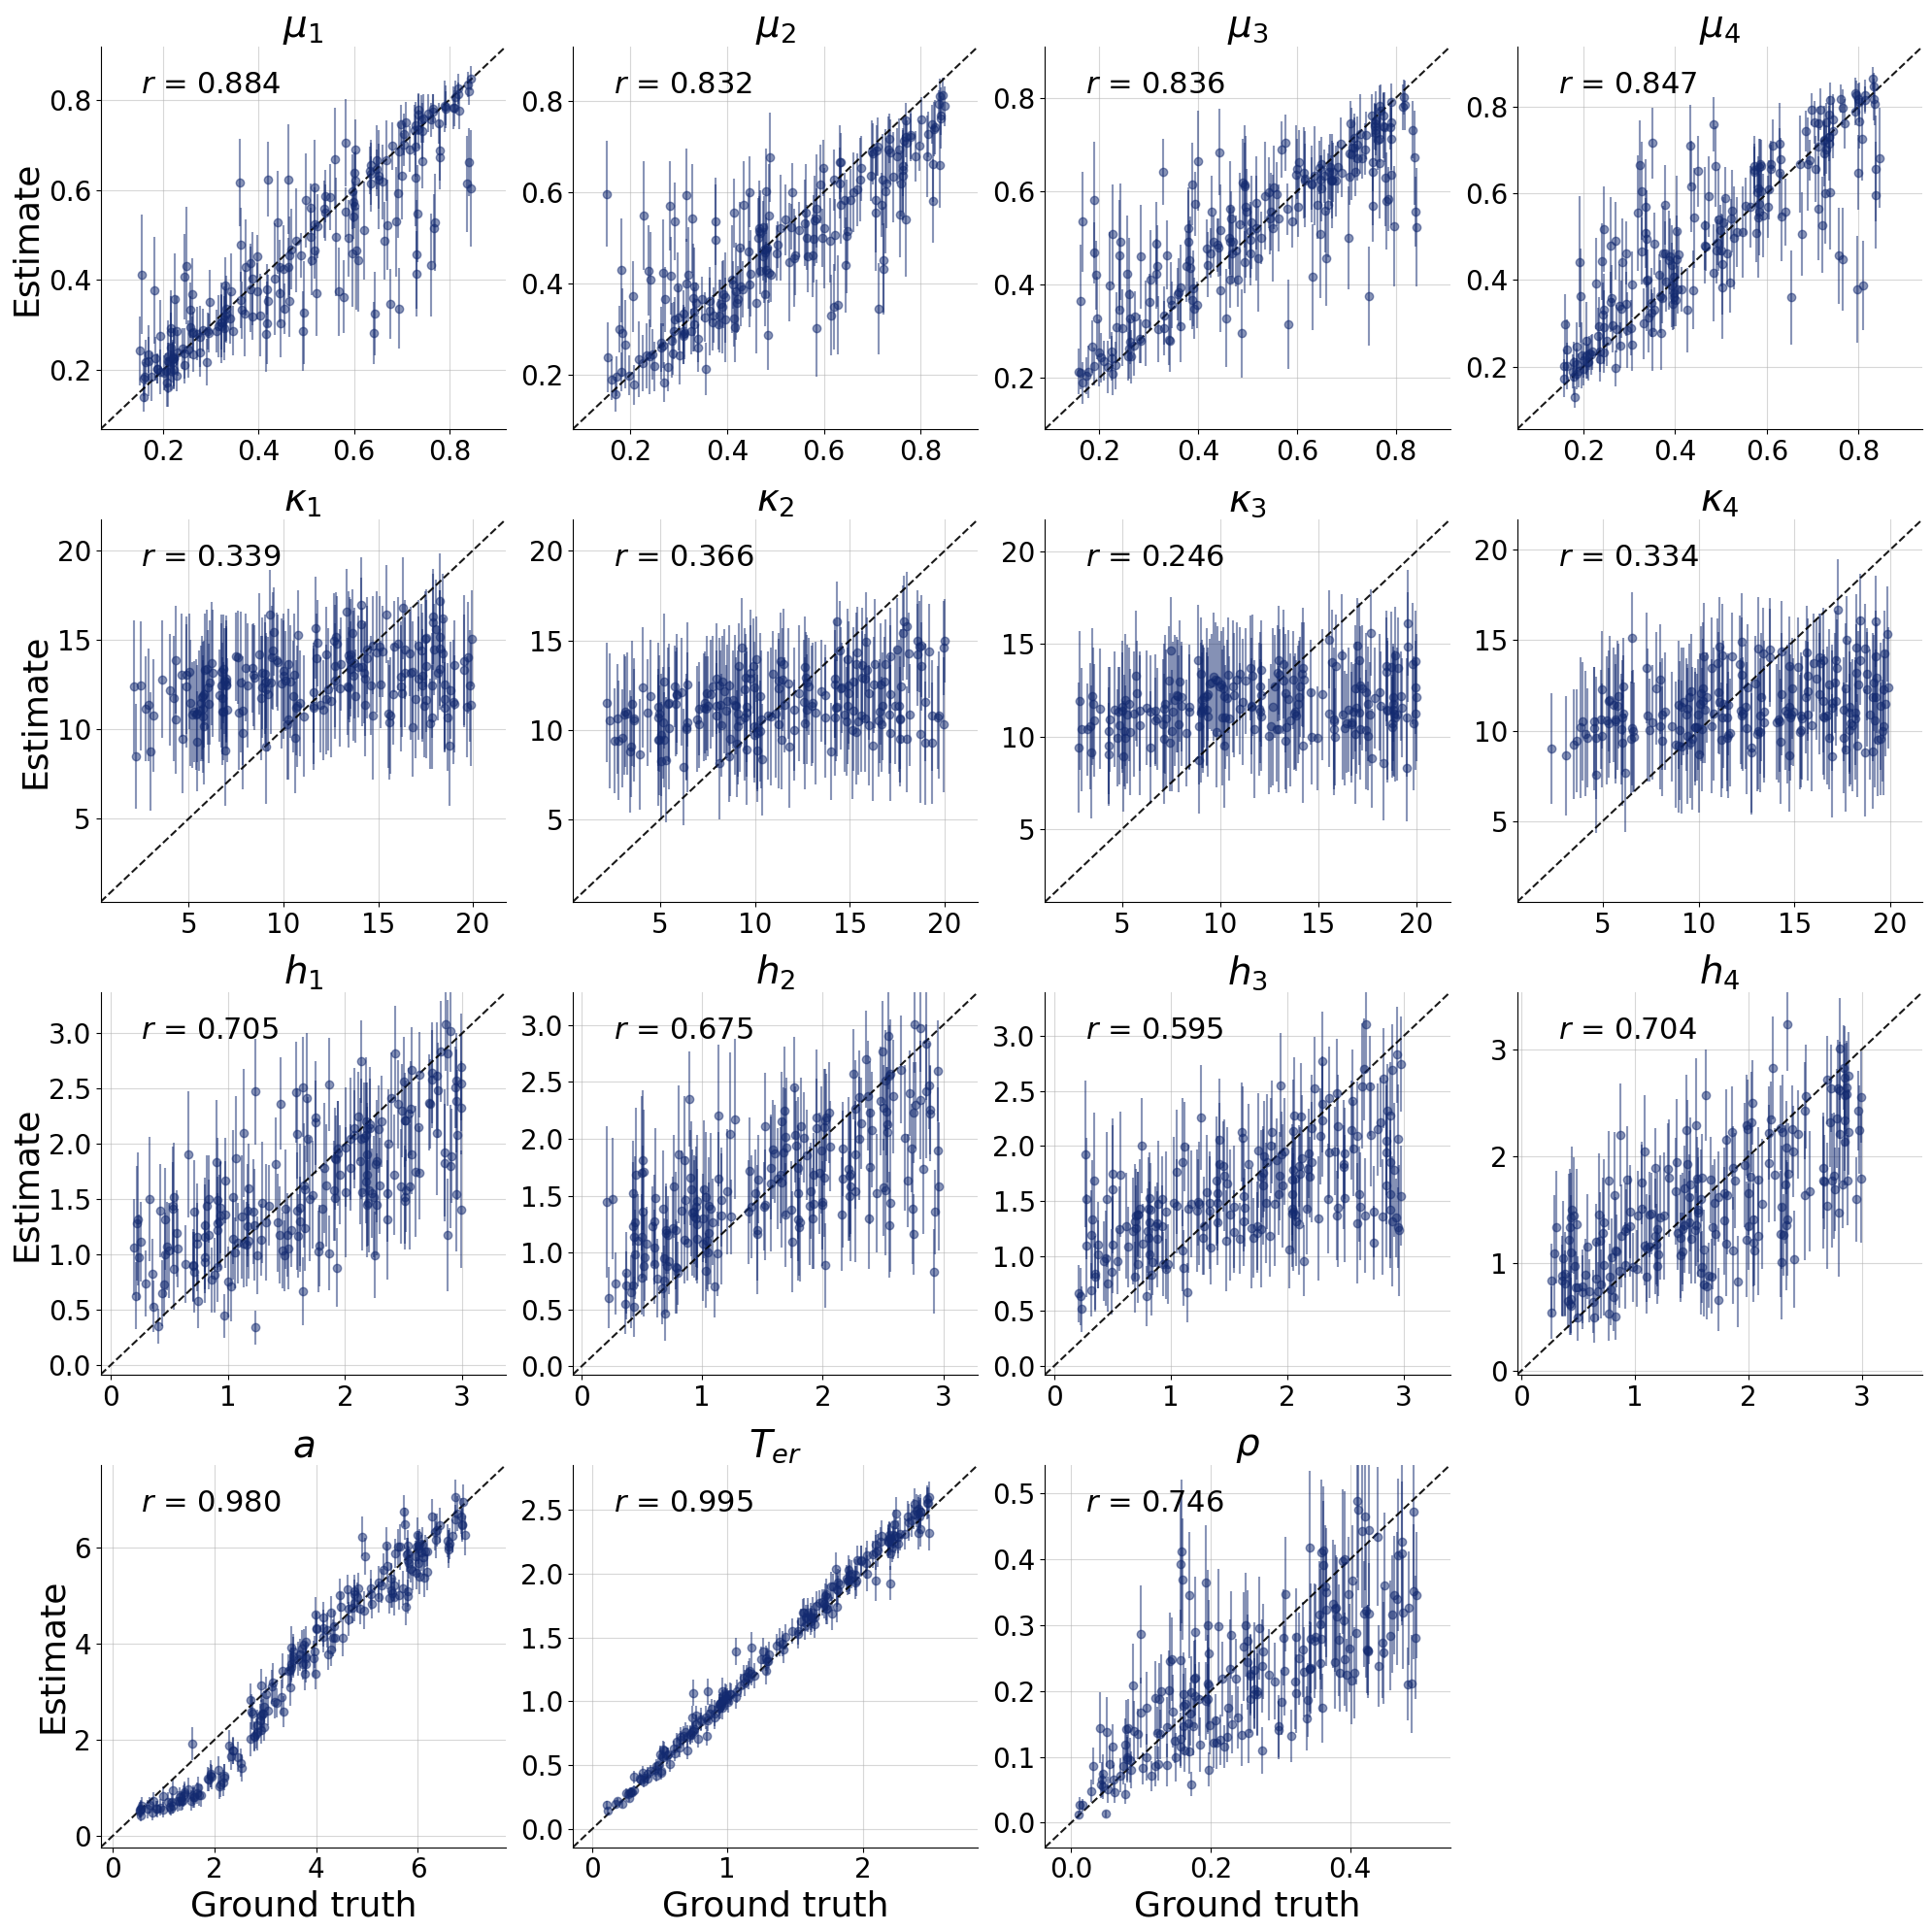

In [69]:
variable_names = [r'$\mu_1$', r'$\mu_2$', r'$\mu_3$', r'$\mu_4$', 
                  r'$\kappa_1$', r'$\kappa_2$', r'$\kappa_3$', r'$\kappa_4$',
                  r'$h_1$', r'$h_2$', r'$h_3$', r'$h_4$',
                  r'$a$', r'$T_{er}$', r'$\rho$']

f = bf.diagnostics.plots.recovery(
    estimates=post_draws, 
    targets=val_sims,
    variable_names = variable_names,
    title_fontsize = 28,
    label_fontsize = 26,
    num_col = 4,
    metric_fontsize = 22,
    tick_fontsize = 20
)

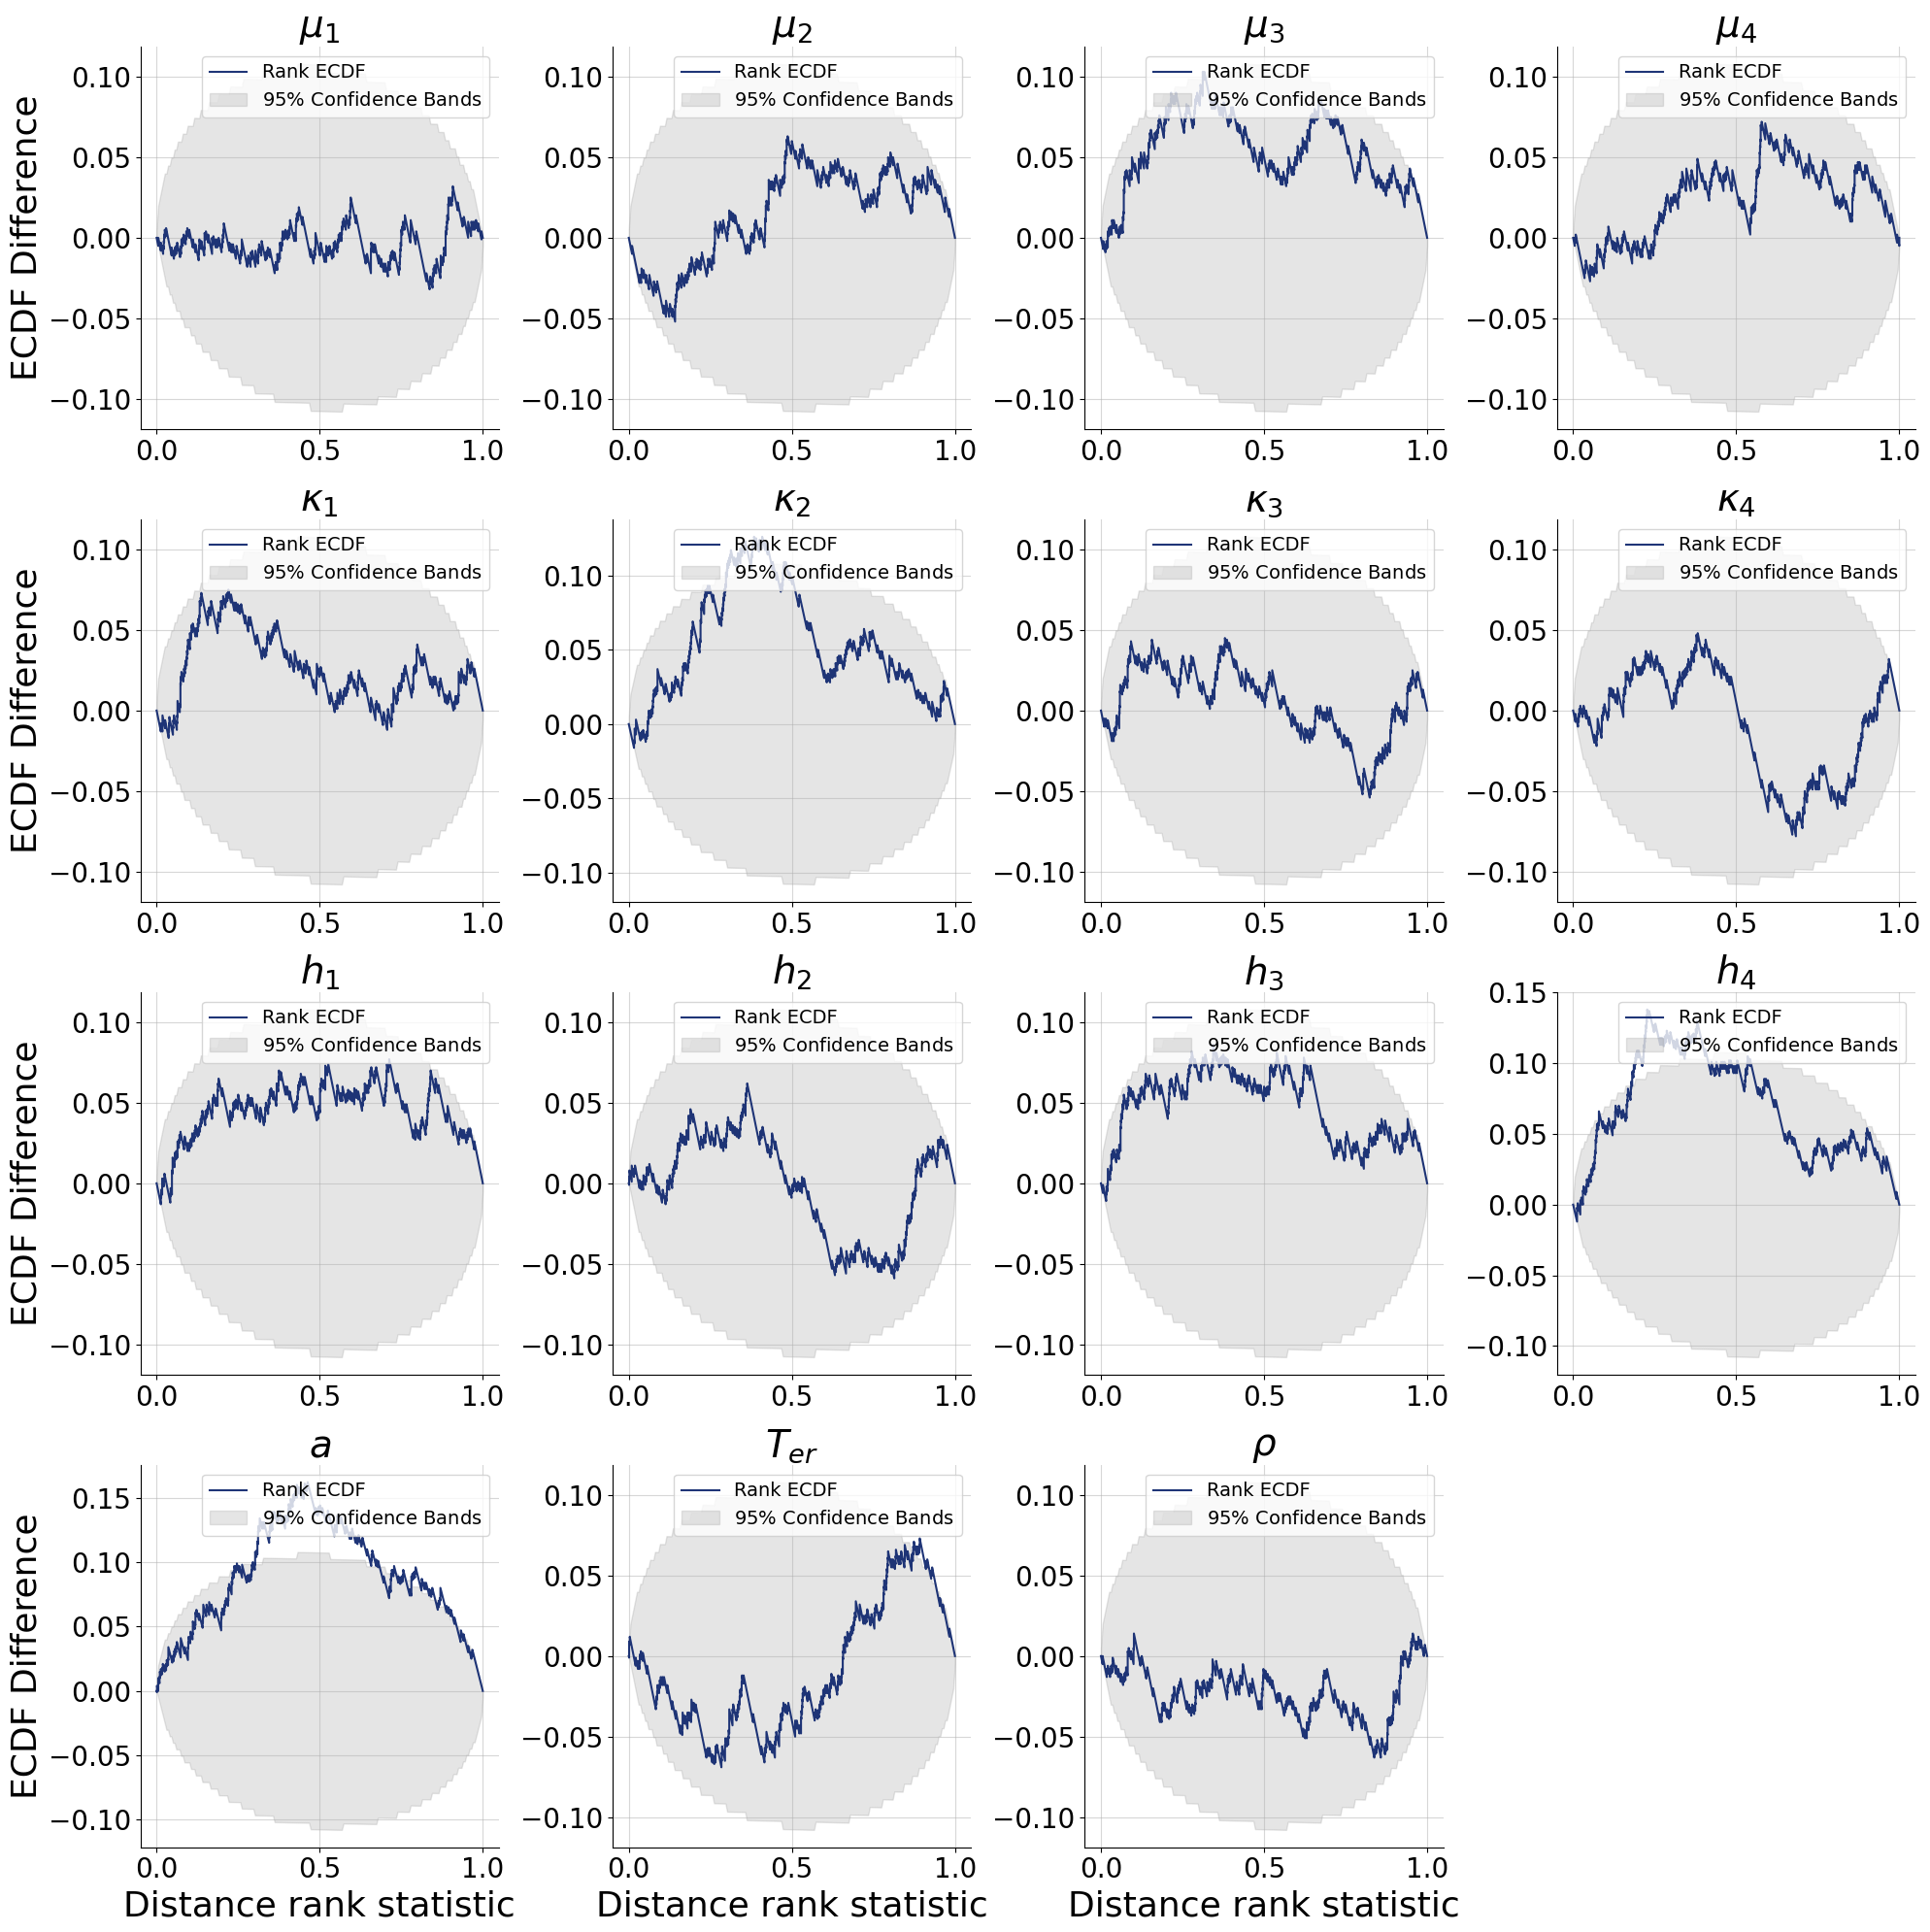

In [20]:
f = bf.diagnostics.plots.calibration_ecdf(
    estimates=post_draws, 
    targets=val_sims,
    difference = True,
    rank_type="distance",
    variable_names = variable_names,
    title_fontsize = 28,
    label_fontsize = 26,
    num_col = 4,
    metric_fontsize = 22,
    tick_fontsize = 20
)